# Simulación del modelo glucolítico S-sistema — Práctica 3
**Biología de Sistemas**

Generación de figuras para el informe a partir de los datos exportados desde COPASI.

Archivos de datos necesarios (misma carpeta que este notebook):
- `steady2000.txt` — simulación del sistema original, 0–2000 min
- `f_alteracion_estructural.txt` — simulación con α₂ = 0.1, g₂₂ = −0.05

## Importaciones y carga de datos

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

# Crear carpeta de figuras si no existe
os.makedirs("figuras", exist_ok=True)

# Cargar datos exportados desde COPASI
orig = np.loadtxt("steady2000.txt", comments="#")
alt  = np.loadtxt("f_alteracion_estructural.txt", comments="#")

colors    = ["red", "blue", "green"]
var_names = ["X1", "X2", "X3"]

print(f"Sistema original:  {orig.shape[0]} puntos, t = {orig[0,0]:.0f}–{orig[-1,0]:.0f} min")
print(f"Sistema alterado:  {alt.shape[0]} puntos, t = {alt[0,0]:.0f}–{alt[-1,0]:.0f} min")
print(f"\nValores en t = 2000 min:")
print(f"  Original  →  X1={orig[-1,1]:.4f}  X2={orig[-1,2]:.4f}  X3={orig[-1,3]:.4f} mmol/l")
print(f"  Alterado  →  X1={alt[-1,1]:.4f}  X2={alt[-1,2]:.4f}  X3={alt[-1,3]:.4f} mmol/l")

Sistema original:  2001 puntos, t = 0–2000 min
Sistema alterado:  2001 puntos, t = 0–2000 min

Valores en t = 2000 min:
  Original  →  X1=0.0500  X2=0.5000  X3=0.1600 mmol/l
  Alterado  →  X1=0.4221  X2=29.7653  X3=9.8091 mmol/l


---
## Apartado (f) — Alteración estructural: α₂ = 0.1, g₂₂ = −0.05

Se modifican dos parámetros del S-sistema que controlan la ecuación de X2 (glucosa-6-fosfato):

| Parámetro | Original | Alterado | Significado |
|-----------|----------|----------|-------------|
| α₂ | 0.060428 | **0.1** | Tasa de síntesis de X2 (actividad glucoquinasa) |
| g₂₂ | −0.45625 | **−0.05** | Auto-inhibición de X2 sobre su propia síntesis |

La figura muestra la comparación lado a lado del comportamiento del sistema:
- **Panel izquierdo (0–100 min, escala lineal):** separación temprana de trayectorias
- **Panel derecho (0–2000 min, escala log):** divergencia completa a largo plazo

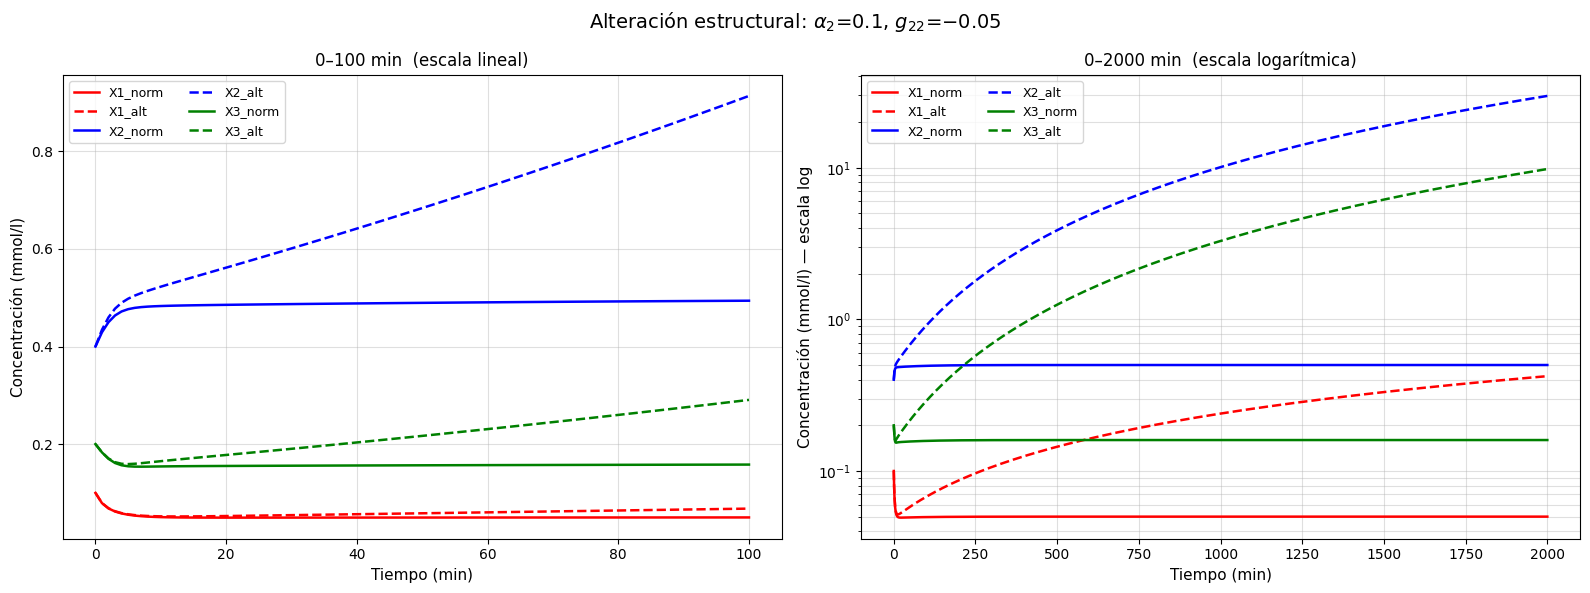

In [2]:
t_max = 100
mask_o = orig[:, 0] <= t_max
mask_a = alt[:, 0]  <= t_max

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(r"Alteración estructural: $\alpha_2$=0.1, $g_{22}$=−0.05", fontsize=14)

# Panel izquierdo: 0–100 min, escala lineal
ax1.set_title("0–100 min  (escala lineal)", fontsize=12)
for i, (name, color) in enumerate(zip(var_names, colors)):
    ax1.plot(orig[mask_o, 0], orig[mask_o, i+1], color=color, linestyle="-",  lw=1.8, label=f"{name}_norm")
    ax1.plot(alt[mask_a, 0],  alt[mask_a, i+1],  color=color, linestyle="--", lw=1.8, label=f"{name}_alt")
ax1.set_xlabel("Tiempo (min)", fontsize=11)
ax1.set_ylabel("Concentración (mmol/l)", fontsize=11)
ax1.legend(fontsize=9, ncol=2)
ax1.grid(True, alpha=0.4)

# Panel derecho: 0–2000 min, escala log
ax2.set_title("0–2000 min  (escala logarítmica)", fontsize=12)
for i, (name, color) in enumerate(zip(var_names, colors)):
    ax2.plot(orig[:, 0], orig[:, i+1], color=color, linestyle="-",  lw=1.8, label=f"{name}_norm")
    ax2.plot(alt[:, 0],  alt[:, i+1],  color=color, linestyle="--", lw=1.8, label=f"{name}_alt")
ax2.set_xlabel("Tiempo (min)", fontsize=11)
ax2.set_ylabel("Concentración (mmol/l) — escala log", fontsize=11)
ax2.set_yscale("log")
ax2.legend(fontsize=9, ncol=2)
ax2.grid(True, alpha=0.4, which="both")

plt.tight_layout()
plt.savefig("figuras/f_comparacion_doble.png", dpi=150, bbox_inches="tight")
plt.show()

---
## Apartado (g) — Escalado de constantes de velocidad ×10

Se estudia el efecto de multiplicar por 10 las constantes de velocidad (α y β) del sistema:

| Condición | Parámetros modificados | Archivo |
|-----------|----------------------|---------|
| Referencia | — | `steady2000.txt` |
| Todas ×10 | α₁, α₂, α₃, β₁, β₂, β₃ | `g_todasx10.txt` |
| Solo X2 ×10 | α₂, β₂ | `g_x2.txt` |

Archivos de datos necesarios: `g_todasx10.txt`, `g_x2.txt` (misma carpeta que el notebook).

In [3]:
todas = np.loadtxt("g_todasx10.txt", comments="#")
x2   = np.loadtxt("g_x2.txt",       comments="#")

print(f"SS referencia   →  X1={orig[-1,1]:.4f}  X2={orig[-1,2]:.4f}  X3={orig[-1,3]:.4f}")
print(f"SS todas ×10    →  X1={todas[-1,1]:.4f}  X2={todas[-1,2]:.4f}  X3={todas[-1,3]:.4f}")
print(f"SS solo X2 ×10  →  X1={x2[-1,1]:.4f}  X2={x2[-1,2]:.4f}  X3={x2[-1,3]:.4f}")

SS referencia   →  X1=0.0500  X2=0.5000  X3=0.1600
SS todas ×10    →  X1=0.0500  X2=0.5000  X3=0.1600
SS solo X2 ×10  →  X1=0.0500  X2=0.5000  X3=0.1600


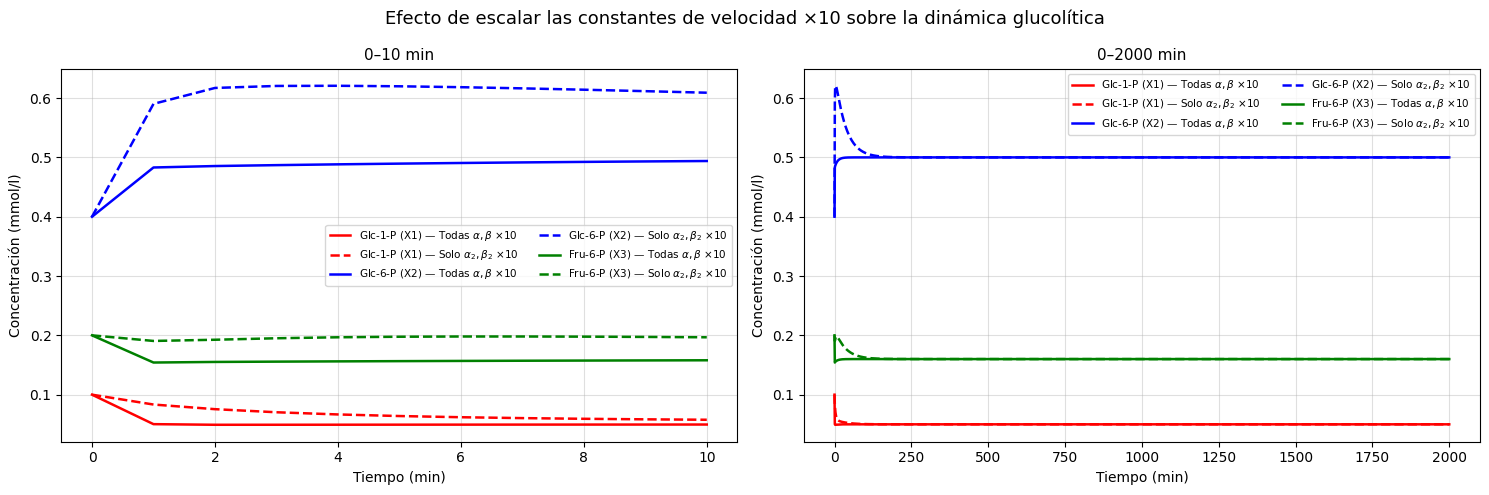

In [6]:
metabolitos = ["Glc-1-P (X1)", "Glc-6-P (X2)", "Fru-6-P (X3)"]

# Solo dos condiciones: todas x10 (sólida) y solo X2 x10 (discontinua)
datasets_g  = [todas,  x2]
line_styles = ["-",    "--"]
line_widths = [1.8,    1.8]
conditions  = [r"Todas $\alpha,\beta$ ×10", r"Solo $\alpha_2,\beta_2$ ×10"]

mask_10 = todas[:, 0] <= 10   # mismo rango para ambos datasets

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Efecto de escalar las constantes de velocidad ×10 sobre la dinámica glucolítica",
             fontsize=13)

for ax, mask, title in [(ax_l, mask_10, "0–10 min"), (ax_r, slice(None), "0–2000 min")]:
    ax.set_title(title, fontsize=11)
    for col_idx, (metabolito, color) in enumerate(zip(metabolitos, colors)):
        for data, ls, lw, cond in zip(datasets_g, line_styles, line_widths, conditions):
            m = mask if mask is not mask_10 or isinstance(mask, slice) else mask
            # para ax_l usar mask_10, para ax_r usar todos los puntos
            d = data[mask] if not isinstance(mask, slice) else data
            ax.plot(d[:, 0], d[:, col_idx+1],
                    color=color, linestyle=ls, lw=lw,
                    label=f"{metabolito} — {cond}")
    ax.set_xlabel("Tiempo (min)", fontsize=10)
    ax.set_ylabel("Concentración (mmol/l)", fontsize=10)
    ax.legend(fontsize=7.5, ncol=2)
    ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("figuras/g_escalado_x10.png", dpi=150, bbox_inches="tight")
plt.show()